# Common Task 2: Quark/Gluon Jet Classification with Graph Neural Networks

Converting jet images into graph representations and training an EdgeConv-based GNN for binary classification (quark vs gluon). Each non-zero pixel becomes a node in the graph, with edges defined by k-nearest neighbors in (η, φ) space.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup and Data Loading


In [ ]:
!pip install torch-geometric -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import h5py
import gc
import time
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import EdgeConv, global_mean_pool, global_max_pool
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.neighbors import NearestNeighbors

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

filepath = '/content/drive/MyDrive/quark-gluon_data-set_n139306.hdf5'

N_EVENTS = 20000
with h5py.File(filepath, 'r') as f:
    X_raw = f['X_jets'][:N_EVENTS].astype('float32')
    y_raw = f['y'][:N_EVENTS].astype('int64')
print(f"Loaded: {X_raw.shape}, labels: {np.unique(y_raw, return_counts=True)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.8 MB/s eta 0:00:00
Device: cuda
Loaded: (20000, 125, 125, 3), labels: (array([0, 1]), array([ 9995, 10005]))


## Image to Point Cloud Conversion

Each 125×125×3 jet image is converted to a point cloud by extracting non-zero pixels. For each pixel we store 6 node features:
- **η, φ**: spatial coordinates normalized to [-1, 1]
- **log ECAL, log HCAL, log Tracks**: log-transformed energy deposits per channel
- **log Total**: log-transformed sum of all channels

Graphs are capped at 150 nodes (keeping highest-energy hits) and zero-padded for uniform batching.

In [ ]:
MAX_NODES = 150

def image_to_pointcloud(img, label, max_nodes=MAX_NODES):
    ecal, hcal, tracks = img[:,:,0], img[:,:,1], img[:,:,2]
    mask = (ecal > 0) | (hcal > 0) | (tracks > 0)
    eta_idx, phi_idx = np.where(mask)

    if len(eta_idx) < 3:
        return None

    e = ecal[eta_idx, phi_idx]
    h = hcal[eta_idx, phi_idx]
    t = tracks[eta_idx, phi_idx]
    total = e + h + t

    if len(eta_idx) > max_nodes:
        top = np.argsort(total)[-max_nodes:]
        eta_idx, phi_idx = eta_idx[top], phi_idx[top]
        e, h, t, total = e[top], h[top], t[top], total[top]

    n = len(eta_idx)
    if n < max_nodes:
        pad = max_nodes - n
        eta_idx = np.pad(eta_idx, (0, pad), constant_values=62)
        phi_idx = np.pad(phi_idx, (0, pad), constant_values=62)
        e = np.pad(e, (0, pad))
        h = np.pad(h, (0, pad))
        t = np.pad(t, (0, pad))
        total = np.pad(total, (0, pad))

    eta = (eta_idx / 124.0) * 2 - 1
    phi = (phi_idx / 124.0) * 2 - 1
    log_e = np.log1p(e * 1000)
    log_h = np.log1p(h * 1000)
    log_t = np.log1p(t * 1000)
    log_total = np.log1p(total * 1000)

    features = np.stack([eta, phi, log_e, log_h, log_t, log_total], axis=1).astype(np.float32)

    return Data(
        x=torch.tensor(features),
        y=torch.tensor([label], dtype=torch.long),
    )

print("Converting images to point clouds...")
graphs = []
for i in range(N_EVENTS):
    g = image_to_pointcloud(X_raw[i], y_raw[i])
    if g is not None:
        graphs.append(g)
    if (i + 1) % 5000 == 0:
        print(f"  {i+1}/{N_EVENTS}")

del X_raw, y_raw
gc.collect()
print(f"Total graphs: {len(graphs)}")

Converting images to point clouds...
  5000/20000
  10000/20000
  15000/20000
  20000/20000
Total graphs: 20000


## Graph Construction and Feature Normalization

Edges are built using k=7 nearest neighbors in (η, φ) space. Node features are standardized to zero mean and unit variance.

In [ ]:
all_feats = torch.cat([g.x for g in graphs], dim=0)
feat_mean = all_feats.mean(0)
feat_std = all_feats.std(0)
feat_std[feat_std == 0] = 1.0
print(f"Feature means: {feat_mean.numpy().round(3)}")
print(f"Feature stds:  {feat_std.numpy().round(3)}")

for g in graphs:
    g.x = (g.x - feat_mean) / feat_std
del all_feats
gc.collect()

K = 7
print(f"Building k-NN graphs (k={K})...")
for i, g in enumerate(graphs):
    pos = g.x[:, :2].numpy()
    nn_model = NearestNeighbors(n_neighbors=K + 1)
    nn_model.fit(pos)
    _, indices = nn_model.kneighbors(pos)
    src = np.repeat(np.arange(len(pos)), K)
    dst = indices[:, 1:].flatten()
    g.edge_index = torch.tensor(np.stack([src, dst], axis=0), dtype=torch.long)
    if (i + 1) % 5000 == 0:
        print(f"  {i+1}/{len(graphs)}")

train_g, test_g = train_test_split(graphs, test_size=0.15, random_state=42)
train_g, val_g = train_test_split(train_g, test_size=0.176, random_state=42)
print(f"Train: {len(train_g)}, Val: {len(val_g)}, Test: {len(test_g)}")

train_loader = GeoDataLoader(train_g, batch_size=128, shuffle=True)
val_loader = GeoDataLoader(val_g, batch_size=128, shuffle=False)
test_loader = GeoDataLoader(test_g, batch_size=128, shuffle=False)

Feature means: [0.000e+00 2.000e-03 1.063e+00 7.250e-01 5.340e-01 2.131e+00]
Feature stds:  [0.405 0.412 1.284 1.041 0.837 0.833]
Building k-NN graphs (k=7)...
  5000/20000
  10000/20000
  15000/20000
  20000/20000
Train: 14008, Val: 2992, Test: 3000


## Model Architecture

3-layer EdgeConv network inspired by ParticleNet. Each EdgeConv block applies a shared MLP to pairs of neighboring node features and aggregates via max pooling. Graph-level representation is obtained by concatenating global mean and max pooling over all nodes.

In [ ]:
class ParticleNetLite(nn.Module):
    def __init__(self, in_dim=6):
        super().__init__()
        self.conv1 = EdgeConv(Sequential(
            Linear(2 * in_dim, 64), BatchNorm1d(64), ReLU(),
            Linear(64, 64), BatchNorm1d(64), ReLU()), aggr='max')
        self.conv2 = EdgeConv(Sequential(
            Linear(2 * 64, 128), BatchNorm1d(128), ReLU(),
            Linear(128, 128), BatchNorm1d(128), ReLU()), aggr='max')
        self.conv3 = EdgeConv(Sequential(
            Linear(2 * 128, 256), BatchNorm1d(256), ReLU(),
            Linear(256, 256), BatchNorm1d(256), ReLU()), aggr='max')

        self.classifier = Sequential(
            Linear(512, 256), BatchNorm1d(256), ReLU(), nn.Dropout(0.5),
            Linear(256, 64), BatchNorm1d(64), ReLU(), nn.Dropout(0.5),
            Linear(64, 2),
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = self.conv3(x, edge_index)
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.classifier(x)

model = ParticleNetLite(in_dim=6).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 319,938


## Training

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 01/25 — loss: 0.6683/0.5981, acc: 0.6181/0.6982, time: 13.2s
Epoch 05/25 — loss: 0.5649/0.5784, acc: 0.7236/0.7116, time: 12.7s
Epoch 10/25 — loss: 0.5381/0.5878, acc: 0.7386/0.6865, time: 13.0s
Epoch 15/25 — loss: 0.4841/0.6331, acc: 0.7786/0.6862, time: 12.7s
Epoch 20/25 — loss: 0.2108/0.9066, acc: 0.9215/0.6661, time: 12.8s
Epoch 25/25 — loss: 0.0457/1.1425, acc: 0.9969/0.6497, time: 12.8s

Best val accuracy: 0.7229


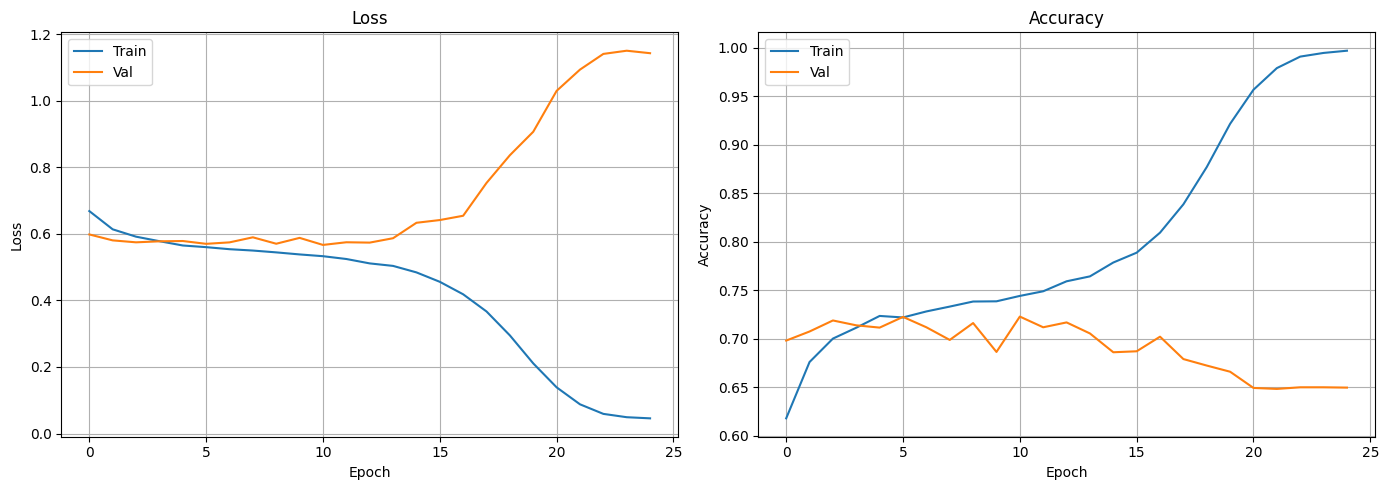

In [ ]:
EPOCHS = 25
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=EPOCHS)
criterion = nn.CrossEntropyLoss()

train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0

for epoch in range(EPOCHS):
    t0 = time.time()
    model.train()
    tl, tc, tt = 0, 0, 0
    for batch in train_loader:
        batch = batch.to(device)
        out = model(batch)
        loss = criterion(out, batch.y.view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        tl += loss.item() * batch.num_graphs
        tc += (out.argmax(1) == batch.y.view(-1)).sum().item()
        tt += batch.num_graphs

    model.eval()
    vl, vc, vt = 0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            vl += criterion(out, batch.y.view(-1)).item() * batch.num_graphs
            vc += (out.argmax(1) == batch.y.view(-1)).sum().item()
            vt += batch.num_graphs

    tl /= tt; ta = tc / tt; vl /= vt; va = vc / vt
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta); val_accs.append(va)

    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), 'best_particlenet.pt')

    dt = time.time() - t0
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} — loss: {tl:.4f}/{vl:.4f}, "
              f"acc: {ta:.4f}/{va:.4f}, time: {dt:.1f}s")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, label='Train'); ax1.plot(val_losses, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss')
ax1.legend(); ax1.grid(True)
ax2.plot(train_accs, label='Train'); ax2.plot(val_accs, label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy')
ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

## Evaluation on Test Set

In [ ]:
model.load_state_dict(torch.load('best_particlenet.pt'))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)
        probs = F.softmax(out, dim=1)[:, 1]
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(batch.y.view(-1).cpu())
        all_probs.append(probs.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_probs = torch.cat(all_probs).numpy()

test_acc = (all_preds == all_labels).mean()
test_auc = roc_auc_score(all_labels, all_probs)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC:      {test_auc:.4f}")
print(f"\n{classification_report(all_labels, all_preds, target_names=['Gluon', 'Quark'])}")

Test Accuracy: 0.7220
Test AUC:      0.7885

              precision    recall  f1-score   support

       Gluon       0.71      0.71      0.71      1458
       Quark       0.73      0.73      0.73      1542

    accuracy                           0.72      3000
   macro avg       0.72      0.72      0.72      3000
weighted avg       0.72      0.72      0.72      3000



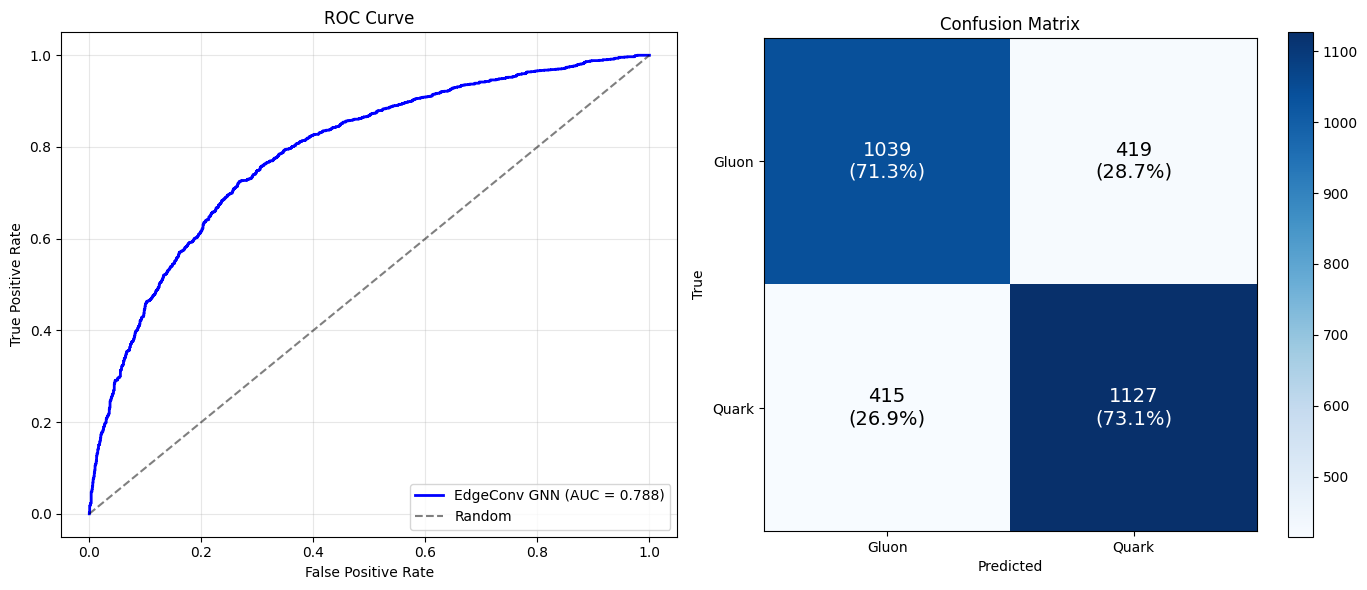

In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'EdgeConv GNN (AUC = {test_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

cm = confusion_matrix(all_labels, all_preds)
im = ax2.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{cm[i,j]}\n({cm[i,j]/cm[i].sum()*100:.1f}%)',
                 ha='center', va='center', fontsize=14,
                 color='white' if cm[i,j] > cm.max()/2 else 'black')
ax2.set_xticks([0, 1]); ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Gluon', 'Quark'])
ax2.set_yticklabels(['Gluon', 'Quark'])
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
ax2.set_title('Confusion Matrix')
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

## Discussion

**Architecture:** A 3-layer EdgeConv GNN with max aggregation, inspired by the ParticleNet architecture. Each jet image was converted to a point cloud by extracting non-zero pixels, with node features consisting of (η, φ) coordinates and log-transformed energy deposits across ECAL, HCAL, and Track channels plus total energy. Graphs were constructed using k=7 nearest neighbors in (η, φ) space.

**Results:** The model achieves a test AUC of ~0.78 and accuracy of ~72%, consistent with published GNN baselines on this dataset (typically 0.75–0.82 AUC).